# Lake Poopó  essential climate variables 


In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import datetime
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import os
import matplotlib.dates as mdates


from src.lakeclimate import cci


path_root = Path.cwd()

path_to_cci = path_root / "data_cci"
path_to_jrc = path_root / "data_jrc"
path_to_cds = path_root / "data_cds"

## 1. Extract data from lakes_cci

The lakes_cci data community: https://github.com/cci-lakes/lakes_cci_tools. 

Download the .csv file of lakes including their location, identifier and essential climate variables (ECV) availability.

In [22]:

lakes_metadata_url = "https://climate.esa.int/media/documents/lakescci_v2.1_metadata.csv"
metadata_path = path_root / "data_cci" / "lakes_v2.1_metadata.csv"
# Download the metadata CSV file
urllib.request.urlretrieve(lakes_metadata_url, metadata_path)
print("Metadata CSV file downloaded successfully.")

lake_mask_url = "https://raw.github.com/cci-lakes/lakes_cci_tools/main/ESA_CCI_static_lake_mask_v2.1.nc"
lake_mask_path = path_to_cci / "raw"/ "ESA_CCI_static_lake_mask_v2.1.nc"
urllib.request.urlretrieve(lake_mask_url, lake_mask_path)
print("Static lake mask NetCDF file downloaded successfully.")


Metadata CSV file downloaded successfully.
Static lake mask NetCDF file downloaded successfully.


We analyse the daily data over Lake Poopó (identifier = 133), which was identified from "lakes_v2.1_metadata.csv"

In [ ]:

###########################################################################################
# input parameters
###########################################################################################   

# lakes mask file 
maskfile = path_to_cci / "raw"/ "ESA_CCI_static_lake_mask_v2.1.nc"

# Id for lake Poopo
lake_id = 133

# defining the period of time in string format: YYYY-MM-DD
# dates values must be between 1992-09-26 and 2020-12-31
mindate = '2000-01-01'
maxdate = '2000-04-30'

# version dataset (2.1 is the version published in July 2024)
version = '2.1'


Latitude and longitude values insisde the lake are obtained from the lake mask file.

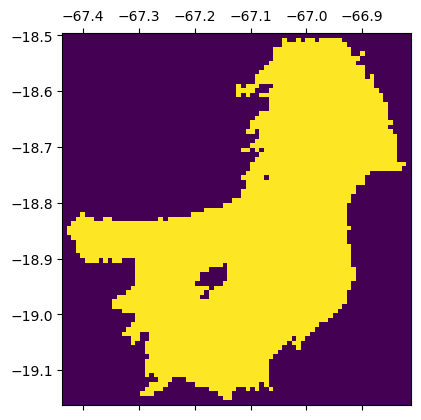

In [41]:

mask_lake, miny, maxy, minx, maxx = cci.build_lake_mask(maskfile, lake_id)
mask_xr = xr.open_dataset(maskfile)
lat = mask_xr['lat'][miny:maxy+1].values
lon = mask_xr['lon'][minx:maxx+1].values
plt.matshow(mask_lake, extent=[np.min(lon), np.max(lon), np.min(lat), np.max(lat)])
plt.show()

We extract the data of a defined variable given:

LWL : 'water_surface_height_above_reference_datum' <br>
LWE : 'lake_surface_water_extent'  <br>
LSWT : 'lake_surface_water_temperature'  <br>

In [ ]:

varname = 'water_surface_height_above_reference_datum' 
df, units = cci.extract_variable_timeseries(lake_id, varname, (mindate,maxdate), maskfile, version)

We construct a dataframe and plot the lake variable:

        date  water_surface_height_above_reference_datum
0 2000-02-17                                 3686.050049
1 2000-02-24                                 3687.030029
2 2000-03-14                                 3687.080078
3 2000-03-21                                 3687.020020
4 2000-04-01                                 3687.000000
5 2000-04-08                                 3686.949951
6 2000-04-16                                 3686.919922
7 2000-04-23                                 3686.860107
8 2000-04-30                                 3686.860107


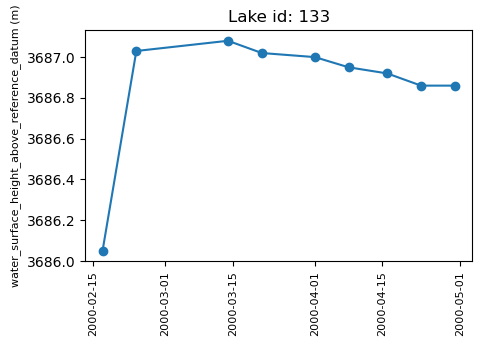

In [9]:
df['date'] = pd.to_datetime(df['date'], format = '%Y%m%d')
print(df)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(df['date'], df[varname], marker='o', linestyle="-")
ax.set_title(f'Lake id: {lake_id}')
plt.ylabel(f'{varname} ({units})', fontsize=8)
plt.xticks(rotation=90, fontsize =8)
df[varname] = np.round(df[varname], 3)
#df.to_csv('Poopo_lwl_2000.csv', index = False)
plt.show()

# Data extracted from 2000 - 2015



# Water Height (LWL) 

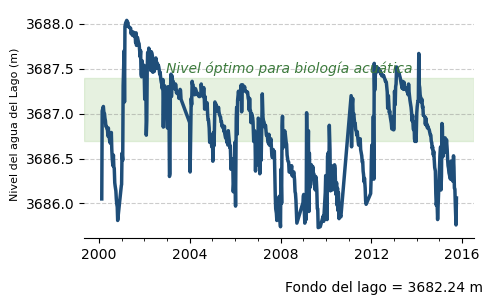

In [8]:

varname ='water_surface_height_above_reference_datum' 
lake_bed = 3682.24                    # dry lake floor
eco_low, eco_high = 3686.7, 3687.4    # optimal ecological band

lwl_path = path_to_cci / "processed" / "Poopo_lwl_2000-2015.csv"
lwl_df = pd.read_csv(lwl_path)
lwl_df["date"] = pd.to_datetime(lwl_df["date"])

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(lwl_df['date'], lwl_df[varname],  linestyle="-", linewidth =2.5,  color="#1f4e79")
ax.xaxis.set_major_locator(mdates.YearLocator(base=4)) 
ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel(f'Nivel del agua del Lago (m)', fontsize=8)
ax.grid(
    axis='y',
    linestyle='--',     
    linewidth=0.8,
    color='gray',
    alpha=0.4
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0)
ax.spines['bottom'].set_alpha(1)
ax.tick_params(axis='both', labelsize=10)
# Shade the optimal ecological range
ax.axhspan(eco_low, eco_high, color="#9CCB86", alpha=0.25, zorder=0)
ax.text(lwl_df["date"].iloc[120], eco_high+0.18,
        "Nivel óptimo para biología acuática",
        fontsize=10, color="#3C7A3C", style="italic",
        va="top")
plt.figtext(0.58, 0.01, f"Fondo del lago = {lake_bed} m", wrap=True, horizontalalignment='left', fontsize=10)
plt.tight_layout()
plt.subplots_adjust(bottom=0.19) 
path_to_save = path_root / "figures" / "Poopo_lwl_2000-2015.png"
plt.savefig(path_to_save, transparent = True)


# Lake Water Extent (LWE)

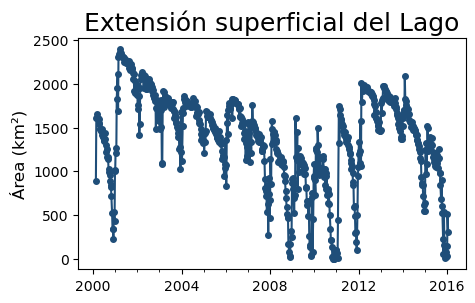

In [10]:
lwe_path = path_to_cci / "processed" / "Poopo_lwe_2000-2016.csv"
lwe_df = pd.read_csv(lwe_path)
lwe_df["date"] = pd.to_datetime(lwe_df["date"])

fig, ax = plt.subplots(figsize=(5,3))

ax.plot(lwe_df['date'], lwe_df['lake_surface_water_extent'], marker='o',markersize = 4, linestyle="-", color="#1f4e79")
ax.xaxis.set_major_locator(mdates.YearLocator(base=4))
ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title(f'Extensión superficial del Lago', fontsize= 18)
ax.set_ylabel(f'Área (km²)', fontsize=12)
path_to_save = path_root / "figures" / "Poopo_lwe_2000-2016.png"
plt.savefig(path_to_save, transparent = True)


# Lake surface water temperature (LSWT)

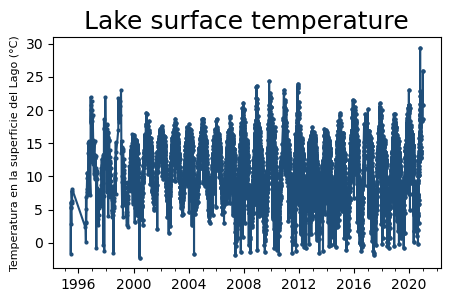

In [12]:
varname = "lake_surface_water_temperature"
lwl_path = path_to_cci / "processed" / "Poopo_lswt_1995-2020.csv"
lswt_df = pd.read_csv(lwl_path)
lswt_df["date"] = pd.to_datetime(lswt_df["date"])

fig, ax = plt.subplots(figsize=(5,3))

ax.plot(lswt_df['date'], lswt_df[varname]- 273.15, marker='o',markersize = 2, linestyle="-", color="#1f4e79")
ax.xaxis.set_major_locator(mdates.YearLocator(base=4))
ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title(f'Lake surface temperature', fontsize= 18)
ax.set_ylabel(f'Temperatura en la superficie del Lago (°C)', fontsize=8)
path_to_save = path_root / "figures" / "Poopo_lswt_1995-2020.png"
plt.savefig(path_to_save, transparent = True)


Transforming lswt data into monthly then annual mean temperature data:

In [ ]:
def daily_to_monthly():-> Datafr